In [62]:

# Address the challenge of optimally placing products across warehouses for a business with high online sales, 
# where accurate calculations are costly and only feasible biweekly. To speed up decision-making, 
# an ML model approximates these results within hours. 
# The model has four hyperparameters to tune, and its output reflects the difference from the expensive baseline. 
# Because the system is dynamic and full of local optima, 
# it requires careful tuning and robust validation to find reliable, near-optimal solutions.
# 

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

X = np.load('initial_inputs.npy')
y = np.load('initial_outputs.npy')

# week1_X = [0.429578, 0.400818, 0.067425, 0.122330]
# week1_y = -10.018190081663906

# X = np.vstack([X, week1_X])
# y = np.append(y, week1_y)

# X_initial and y_initial should already exist from baseline points
X_initial = X.copy()
y_initial = y.copy()

X_weekly_list = []
y_weekly_list = []

# --- WEEKLY UPDATE SECTION ---
new_queries = [
    [0.429578, 0.400818, 0.067425, 0.122330], # Week 1
    [0.473835, 0.502178, 0.427389, 0.310466]  # Week 2
]
new_results = [
    -10.018190081663906, # Week 1
    -2.508400329511655 # Week 2
]

# Create the "Weekly Only" arrays for your Distance and Sensitivity plots
X_weekly = np.array(new_queries)
y_weekly = np.array(new_results)

# Reference for convenience
X_lastweek = X_weekly[-1]
y_lastweek = y_weekly[-1]

# Automatically update your main dataset
X = np.vstack([X_initial, new_queries])
y = np.append(y_initial, new_results)


print('-- inputs X ---')
print(X)
print("X shape=",X.shape)

print('-- outputs y ---')
print(y)
print("y shape=",y.shape)


-- inputs X ---
[[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.33541983 0.9994825

In [64]:
df = pd.DataFrame(X, columns=["x1","x2","x3","x4"])
df['y'] = y
df = df.sort_values(by='y', ascending=False)

print(df.head())
print(df.tail())

# Result sits in 4th Position
# 30  0.429578  0.400818  0.067425  0.122330 -10.018190
# 31  0.473835  0.502178  0.427389  0.310466  -2.508400  --> 1st position

          x1        x2        x3        x4          y
31  0.473835  0.502178  0.427389  0.310466  -2.508400
27  0.577766  0.428772  0.425826  0.249007  -4.025542
24  0.326076  0.472367  0.453192  0.105887  -6.702089
23  0.282138  0.505987  0.530531  0.096302  -7.966775
30  0.429578  0.400818  0.067425  0.122330 -10.018190
          x1        x2        x3        x4          y
22  0.859657  0.919592  0.206139  0.097797 -26.857786
10  0.957135  0.597644  0.766114  0.776210 -27.316396
18  0.985622  0.666933  0.156783  0.856535 -28.903274
20  0.683486  0.902770  0.335420  0.999483 -29.427091
25  0.948389  0.894513  0.851638  0.552196 -32.625660


In [65]:
sorted_idx = np.argsort(y)[::-1]
best_idx      = sorted_idx[0]
second_idx    = sorted_idx[1]
third_idx     = sorted_idx[2]

x_best  = X[best_idx]
x_second_best = X[second_idx]
x_third_best  = X[third_idx]

y_best        = y[best_idx]
y_second_best = y[second_idx]
y_third_best  = y[third_idx]

print(sorted_idx)

print(f"Current Best x_idx: {best_idx}")
print(f"Current Best x: {x_best}")
print(f"Current Best y: {y_best}")

print(f"Current 2nd Best x: {x_second_best}, y:{y_second_best}")
print(f"Current 3nd Best x: {x_third_best}, y:{y_third_best}")

[31 27 24 23 30  4 21  2  6  9 16 28 11 19  1  5  7  3 13 12  8 14 17 26
  0 29 15 22 10 18 20 25]
Current Best x_idx: 31
Current Best x: [0.473835 0.502178 0.427389 0.310466]
Current Best y: -2.508400329511655
Current 2nd Best x: [0.57776561 0.42877174 0.42582587 0.24900741], y:-4.025542281908162
Current 3nd Best x: [0.32607578 0.4723669  0.453192   0.10588734], y:-6.702089254839066


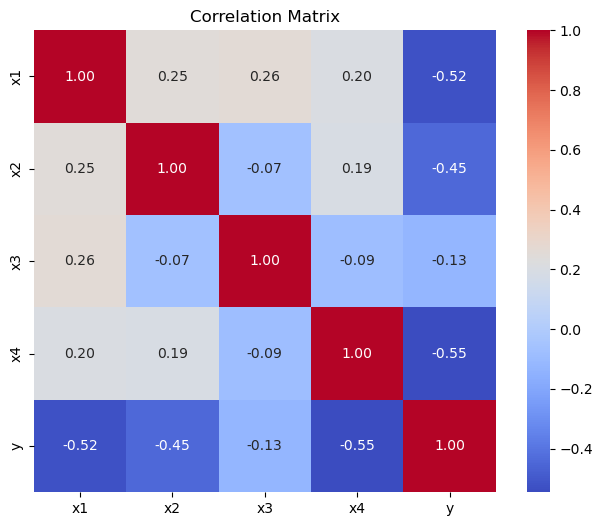

In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)
plt.title("Correlation Matrix")
plt.show()

In [67]:
# x1, x2 and x4 have larger negative correlation
# as these value x1, x2 and x4 increase y descreases, i.e. y becomre more negative and moves away from baseline (0 - best result)
# so we have to reduce x1, x2 and x4 values to bring back y to near 0
# x3 has little correlation

In [94]:
from scipy.stats import norm

def upper_confidence_bound(mu, sigma, kappa=2.0):
    """
    kappa = 1.96  -> 95% confidence (Balanced)
    kappa = 2.576 -> 99% confidence (More Exploration)
    """
    return mu + kappa * sigma
    
def expected_improvement(mu, sigma, y_best, xi=0.01):
    with np.errstate(divide='warn'):
        improvement = mu - y_best - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei


In [82]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from scipy.stats import norm
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# week1
# kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=[0.5]*4, 
#                                       length_scale_bounds=(1e-2, 1e5), 
#                                       nu=2.5)
# gp = GaussianProcessRegressor(kernel=kernel, alpha=0.1, normalize_y=True, n_restarts_optimizer=10)

# # week2
# After looking at the correlation matrix, x3 has little contribution to y and hence increasing the scale to reduce its contribution
# thereby treating this model from 4D to 3D
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=[1.0, 1.0, 5.0, 1.0], 
                                      length_scale_bounds=[
                                          (1e-2, 1e3),
                                          (1e-2, 1e3),
                                          (5.0, 1e5),
                                          (1e-2, 1e3)], 
                                      nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-4, normalize_y=True, n_restarts_optimizer=10)

gp.fit(X, y)

print(f"Optimized Kernel: {gp.kernel_}")
print(f"Training R^2 Score: {gp.score(X, y)}")
print(f"Total variance accounted for as noise: {gp.alpha}")

# week 1 
# Optimized Kernel: 1.02**2 * Matern(length_scale=[0.264, 0.172, 5, 0.439], nu=2.5)
# Training R^2 Score: 0.9999999068825886
# Total variance accounted for as noise: 0.0001

# to 
# week 2
# Optimized Kernel: 1.02**2 * Matern(length_scale=[0.264, 0.172, 5, 0.439], nu=2.5)
# Training R^2 Score: 0.9999999068821188
# Total variance accounted for as noise: 0.0001

Optimized Kernel: 0.994**2 * Matern(length_scale=[0.275, 0.179, 5, 0.455], nu=2.5)
Training R^2 Score: 0.9999998868390866
Total variance accounted for as noise: 0.0001


In [83]:
# Predict
X_grid = np.random.uniform(0, 1, size=(100000, 4))
mu, sigma = gp.predict(X_grid, return_std=True)

sigma = sigma.reshape(-1, 1)
mu = mu.reshape(-1, 1)


In [84]:
# kappa = 2.0 is a great starting point for week 1
kappa=2.0
ucb_values = upper_confidence_bound(mu, sigma, kappa)

ucb_next_idx = np.argmax(ucb_values)
ucb_next_query = X_grid[ucb_next_idx]

print(f"--- Optimization Results ---")
print(f"UCB Score with kappa: {kappa}")
print(f"Current Best y: {y_best}")
print(f"Suggested next: {ucb_next_query}")


--- Optimization Results ---
UCB Score with kappa: 2.0
Current Best y: -2.508400329511655
Suggested next: [0.34409802 0.49683927 0.94538326 0.55836915]


In [85]:
xi=0.01
ei_values = expected_improvement(mu, sigma, y_best, xi)

# Get the next best point
ei_next_idx = np.argmax(ei_values)
ei_next_query = X_grid[ei_next_idx]

print(f"--- Optimization Results ---")
print(f"expected_improvement with xi: {xi}")
print(f"Current Best y: {y_best}")
print(f"Suggested next: {ei_next_query}")


--- Optimization Results ---
expected_improvement with xi: 0.01
Current Best y: -2.508400329511655
Suggested next: [0.40006516 0.48988945 0.92623014 0.44093101]


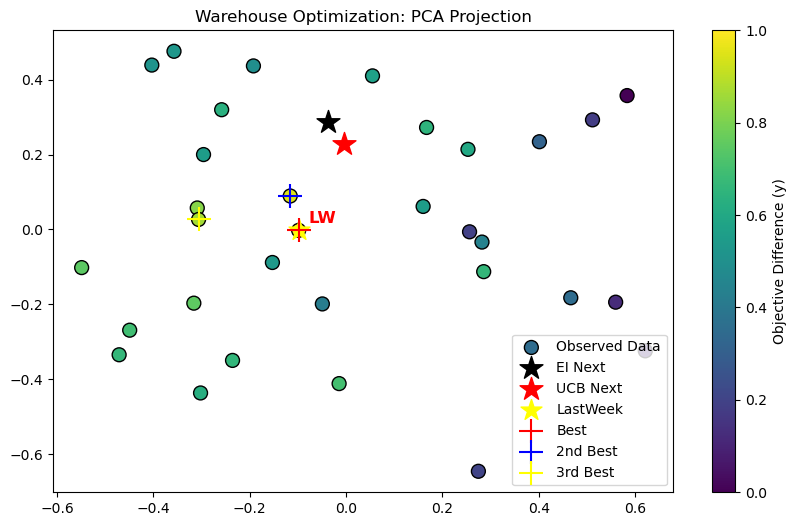

[[ 0.57959074  0.62388201  0.08728183  0.51694071]
 [ 0.49407828 -0.25866847  0.74428592 -0.36744489]]


In [86]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

suggested_ei_pca = pca.transform(ei_next_query.reshape(1, -1))
suggested_ucb_pca = pca.transform(ucb_next_query.reshape(1, -1))

best_pca = pca.transform(x_best.reshape(1, -1))
second_best_pca = pca.transform(x_second_best.reshape(1, -1))
third_best_pca = pca.transform(x_third_best.reshape(1, -1))

X_lastweek_array = np.array(X_lastweek) 
lastweek_pca = pca.transform(X_lastweek_array.reshape(1, -1))

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', s=100, edgecolors='k', label='Observed Data')
plt.scatter(suggested_ei_pca[:, 0], suggested_ei_pca[:, 1], c='black', marker='*', s=300, label='EI Next')
plt.scatter(suggested_ucb_pca[:, 0], suggested_ucb_pca[:, 1], c='red', marker='*', s=300, label='UCB Next')

plt.scatter(lastweek_pca[:, 0], lastweek_pca[:, 1], c='yellow', marker='*', s=250, label='LastWeek')
plt.text(lastweek_pca[:, 0] + 0.02, lastweek_pca[:, 1] + 0.02, 'LW', fontsize=12, fontweight='bold', color='red')

plt.scatter(best_pca[:, 0], best_pca[:, 1], c='red', marker='+', s=300, label='Best')
plt.scatter(second_best_pca[:, 0], second_best_pca[:, 1], c='blue', marker='+', s=300, label='2nd Best')
plt.scatter(third_best_pca[:, 0], third_best_pca[:, 1], c='yellow', marker='+', s=300, label='3rd Best')
plt.colorbar(label='Objective Difference (y)')
plt.title('Warehouse Optimization: PCA Projection')
plt.legend()
plt.show()

print(pca.components_)

In [87]:
# week 1 
# Result sits in 4th Position
# 30  0.429578  0.400818  0.067425  0.122330 -10.018190
# I tune the kernel to reduce noise, and then generate next query, still the query got stuck around the same region as previous week query
# I took the decision to make X3 scale large so that x1,x2,x4 decide the BO
# Regenerate the kernel and now kernel looks better with smaller x1,x2,x4
# The new query point is moving along the cetre in PCA diagram

# week2
# --- Optimization Results ---
# expected_improvement with xi: 0.01
# Current Best y: -4.025542281908162
# Suggested next: [0.47383558 0.50217877 0.42738919 0.31046635]


In [88]:
# import plotly.express as px
# import pandas as pd

# # Create a DataFrame for easy plotting
# df = pd.DataFrame(X, columns=['X1', 'X2', 'X3', 'X4'])
# df['Side_Effects_Score'] = y

# fig = px.scatter_3d(df, x='X1', y='X2', z='X4',
#                     color='Side_Effects_Score', 
#                     title="3D Drug Discovery Landscape",
#                     color_continuous_scale='Viridis')
# fig.show()

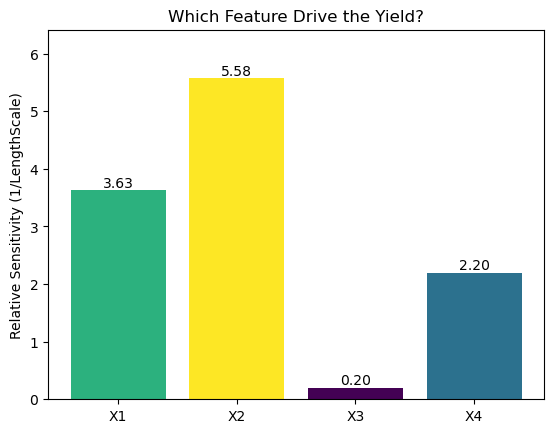

In [89]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# 1. Feature Sensitivity (Length Scales)
# We plot 1/Length_Scale because a higher value = higher importance
lscales = gp.kernel_.k2.length_scale
sensitivities = 1 / lscales
names = ['X1', 'X2', 'X3', 'X4']

# Create a colormap (e.g., 'viridis', 'plasma', or 'coolwarm') 
# and normalize it based on the sensitivity values
norm = Normalize(vmin=min(sensitivities), vmax=max(sensitivities))
colors = cm.viridis(norm(sensitivities))

# Create the bar plot using the 'colors' array
bars = plt.bar(names, sensitivities, color=colors)

# Create the bar plot and store the container in 'bars'
# bars = plt.bar(names, sensitivities, color='teal')
plt.ylabel('Relative Sensitivity (1/LengthScale)')
plt.title('Which Feature Drive the Yield?')

# Annotate each bar with its value
for bar in bars:
    yval = bar.get_height()
    # We place the text at (x_center, y_top)
    # va='bottom' ensures the text sits just above the bar
    text_location = bar.get_x() + bar.get_width()/2
    plt.text(text_location, yval, f'{yval:.2f}', va='bottom', ha='center', fontsize=10)

# Adjust y-limit slightly to make room for the labels at the top
plt.ylim(0, max(sensitivities) * 1.15)

plt.show()

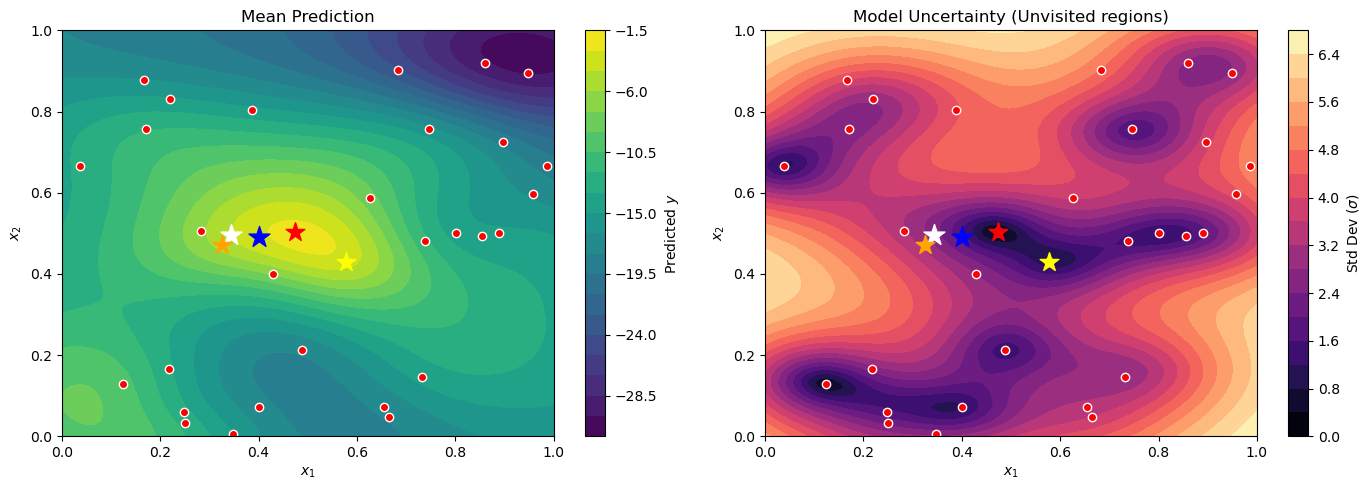

In [95]:
import numpy as np
import matplotlib.pyplot as plt

res=100
x_range = np.linspace(0, 1, res)
X1, X2 = np.meshgrid(x_range, x_range)

# Create a template of the "Best" point
# This ensures all 4 dimensions are present
# 1. Create 10,000 rows of 'Best' values
# res**2 = 10000
points = np.tile(x_best, (10000, 1)) 

# Overwrite the two dimensions you want to visualize
points[:, 0] = X1.ravel() # Variable x1 on x-axis
points[:, 1] = X2.ravel() # Variable x2 on y-axis

mu, sigma = gp.predict(points, return_std=True)

ucb_values = upper_confidence_bound(mu, sigma, kappa=2.0)
ei_values = expected_improvement(mu, sigma, y_best, xi=0.01)

ei_map = ei_values.reshape(X1.shape)
ucb_map = ucb_values.reshape(X1.shape)
mu_map = mu.reshape(X1.shape)
sigma_map = sigma.reshape(X1.shape)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Predicted Mean (mu)
contour_mean = ax[0].contourf(X1, X2, mu_map, levels=20, cmap='viridis')
fig.colorbar(contour_mean, ax=ax[0], label='Predicted $y$')
ax[0].scatter(X[:, 0], X[:, 1], c='red', edgecolors='white', label='Observed Points')
ax[0].scatter(ucb_next_query[0], ucb_next_query[1], c='white', marker='*', s=250, label='Next UCB')
ax[0].scatter(ei_next_query[0], ei_next_query[1], c='blue', marker='*', s=250, label='Next EI')

ax[0].scatter(x_best[0], x_best[1], c='red', marker='*', s=200, label='Best')
ax[0].scatter(x_second_best[0], x_second_best[1], c='yellow', marker='*', s=200, label='2nd Best')
ax[0].scatter(x_third_best[0], x_third_best[1], c='orange', marker='*', s=200, label='3rd Best')

ax[0].set_title(f'Mean Prediction')
ax[0].set_xlabel('$x_1$')
ax[0].set_ylabel('$x_2$')

# Plot Prediction Uncertainty (Standard Deviation)
contour_std = ax[1].contourf(X1, X2, sigma_map, levels=20, cmap='magma')
fig.colorbar(contour_std, ax=ax[1], label='Std Dev ($\sigma$)')
ax[1].scatter(X[:, 0], X[:, 1], c='red', edgecolors='white', label='Observed Points')
ax[1].scatter(ucb_next_query[0], ucb_next_query[1], c='white', marker='*', s=250, label='Next UCB')
ax[1].scatter(ei_next_query[0], ei_next_query[1], c='blue', marker='*', s=250, label='Next EI')

ax[1].scatter(x_best[0], x_best[1], c='red', marker='*', s=200, label='Best')
ax[1].scatter(x_second_best[0], x_second_best[1], c='yellow', marker='*', s=200, label='2nd Best')
ax[1].scatter(x_third_best[0], x_third_best[1], c='orange', marker='*', s=200, label='3rd Best')

ax[1].set_title('Model Uncertainty (Unvisited regions)')
ax[1].set_xlabel('$x_1$')
ax[1].set_ylabel('$x_2$')

plt.tight_layout()
plt.show()

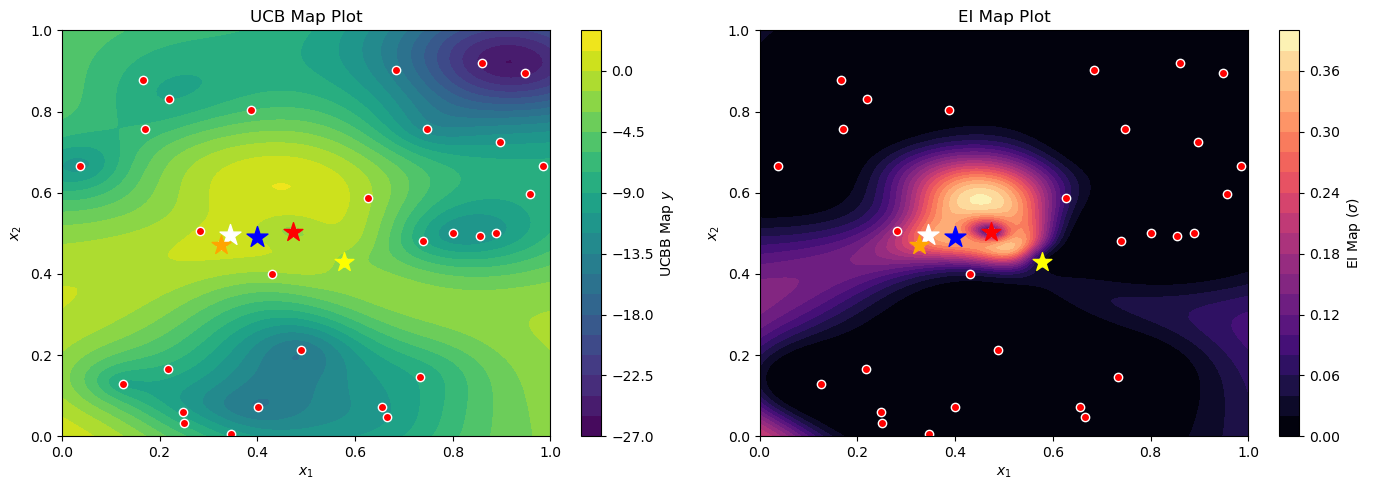

In [91]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# UCB Map Plot
contour_mean = ax[0].contourf(X1, X2, ucb_map, levels=20, cmap='viridis')
fig.colorbar(contour_mean, ax=ax[0], label='UCBB Map $y$')
ax[0].scatter(X[:, 0], X[:, 1], c='red', edgecolors='white', label='Observed Points')
ax[0].scatter(ucb_next_query[0], ucb_next_query[1], c='white', marker='*', s=250, label='Next UCB')
ax[0].scatter(ei_next_query[0], ei_next_query[1], c='blue', marker='*', s=250, label='Next EI')

ax[0].scatter(x_best[0], x_best[1], c='red', marker='*', s=200, label='Best')
ax[0].scatter(x_second_best[0], x_second_best[1], c='yellow', marker='*', s=200, label='2nd Best')
ax[0].scatter(x_third_best[0], x_third_best[1], c='orange', marker='*', s=200, label='3rd Best')


ax[0].set_title(f'UCB Map Plot')
ax[0].set_xlabel('$x_1$')
ax[0].set_ylabel('$x_2$')

# EI Map Plot
contour_std = ax[1].contourf(X1, X2, ei_map, levels=20, cmap='magma')
fig.colorbar(contour_std, ax=ax[1], label='EI Map ($\sigma$)')
ax[1].scatter(X[:, 0], X[:, 1], c='red', edgecolors='white', label='Observed Points')
ax[1].scatter(ucb_next_query[0], ucb_next_query[1], c='white', marker='*', s=250, label='Next UCB')
ax[1].scatter(ei_next_query[0], ei_next_query[1], c='blue', marker='*', s=250, label='Next EI')

ax[1].scatter(x_best[0], x_best[1], c='red', marker='*', s=200, label='Best')
ax[1].scatter(x_second_best[0], x_second_best[1], c='yellow', marker='*', s=200, label='2nd Best')
ax[1].scatter(x_third_best[0], x_third_best[1], c='orange', marker='*', s=200, label='3rd Best')

ax[1].set_title('EI Map Plot')
ax[1].set_xlabel('$x_1$')
ax[1].set_ylabel('$x_2$')

plt.tight_layout()
plt.show()


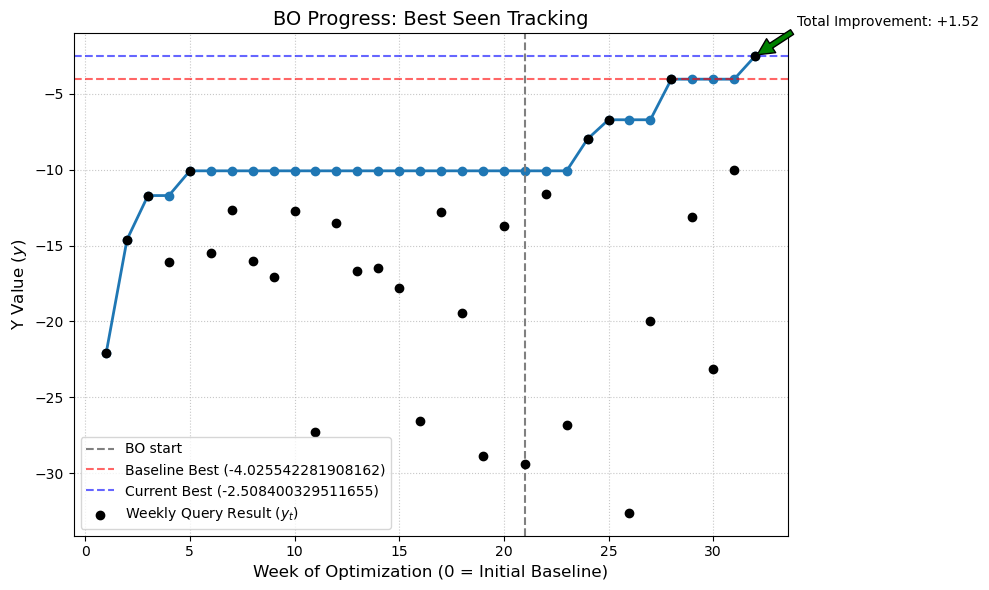

In [92]:
# Convergence Report
y_observed = y
baseline_best = np.max(y_initial)

weekly = np.arange(1, len(y_observed) + 1)
best_seen_trace = np.maximum.accumulate(y_observed)

bo_start_idx = 20  # zero-based index of first BO point

plt.figure(figsize=(10,6))
plt.plot(weekly, best_seen_trace, marker='o', linewidth=2)

# Vertical line separating phases
plt.axvline(x=bo_start_idx + 1, color='gray', linestyle='--', label='BO start')

# Plot the baseline best as a horizontal reference
plt.axhline(y=baseline_best, color='red', linestyle='--', alpha=0.6, label=f'Baseline Best ({baseline_best})')
plt.axhline(y=y_best, color='blue', linestyle='--', alpha=0.6, label=f'Current Best ({y_best})')

# Plot the individual weekly results
plt.scatter(weekly[0:], y, color='black', zorder=3, label='Weekly Query Result ($y_t$)')

plt.title('BO Progress: Best Seen Tracking', fontsize=14)
plt.xlabel('Week of Optimization (0 = Initial Baseline)', fontsize=12)
plt.ylabel('Y Value ($y$)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

# Highlight improvement
improvement = best_seen_trace[-1] - baseline_best
if improvement > 0:
    plt.annotate(f'Total Improvement: +{improvement:.2f}', 
                 xy=(weekly[-1], best_seen_trace[-1]), 
                 xytext=(weekly[-1]+2, best_seen_trace[-1] + 2),
                 arrowprops=dict(facecolor='green', shrink=0.05))

plt.tight_layout()
plt.show()



In [93]:
# Metrics History
from scipy.spatial.distance import euclidean

ucb_next_query_dist = euclidean(ucb_next_query, x_best)
ei_next_query_dist = euclidean(ei_next_query, x_best)

print(f"Distance from Best X, ucb_next_query_dist:{ucb_next_query_dist}")
print(f"Distance from Best X, ei_next_query_dist:{ei_next_query_dist}")

print(f"X_best:{x_best}")
print(f"y_best:{y_best}")
# Calculate prediction Error
x_next = ei_next_query

y_pred, sigma = gp.predict(x_next.reshape(1, -1), return_std=True)
confidence_value = sigma[0]

print(f"======== NextQuery==========") 
print(f"Query:{x_next}")
print(f"Model Confidence (σ): {confidence_value:.4f}")
print(f"Model Predicted: {y_pred[0]:.2f}")

## fill in weekly
# y_actual = -1.6268381341133806e-44
# prediction_error = np.abs(y_pred[0] - y_actual)
# print(f"Actual Result:  {y_actual:.2f}")
# print(f"Prediction Error: {prediction_error:.2f}")
print(f"Distance from X_best:{euclidean(x_next, x_best)}")

print("==================") 
print("Weekly Queries:") 
for i, (query, result) in enumerate(zip(new_queries, new_results), start=1):
    print(f"Week: {i} | Query: {query} | Result: {result:.8e}")

print("==================") 
print("Next Week Query: EI")
print(x_next)


# new_queries = [
#     [0.429578, 0.400818, 0.067425, 0.122330], # Week 1
#     [0.473835, 0.502178, 0.427389, 0.310466]  # Week 2
# ]
# new_results = [
#     -10.018190081663906, # Week 1
#     -2.508400329511655 # Week 2
# ]

# week3 ->[0.388395-0.482827-0.767113-0.471489] EI exploitation

Distance from Best X, ucb_next_query_dist:0.5887564958380787
Distance from Best X, ei_next_query_dist:0.5210149664763791
X_best:[0.473835 0.502178 0.427389 0.310466]
y_best:-2.508400329511655
======== NextQuery==========
Query:[0.40006516 0.48988945 0.92623014 0.44093101]
Model Confidence (σ): 3.1903
Model Predicted: -4.24
Distance from X_best:0.5210149664763791
Weekly Queries:
Week: 1 | Query: [0.429578, 0.400818, 0.067425, 0.12233] | Result: -1.00181901e+01
Week: 2 | Query: [0.473835, 0.502178, 0.427389, 0.310466] | Result: -2.50840033e+00
Next Week Query: EI
[0.40006516 0.48988945 0.92623014 0.44093101]
